In [1]:
import aotools
import numpy
import matplotlib.pyplot as plt
from astropy.io import fits
from PIL import Image
from tqdm import tqdm, trange, tqdm_notebook
import scipy.signal
import sys,os

In [2]:
data = fits.getdata('tabai5mm.fits')
data[:,:,0:2]=0
array_size=128
padding=2
wavelength=833e-3 #(this is the wavelength data was taken at in microns)
wavelength_m=833e-9
diameter=5e-3 #(pupil diameter in m)
psf_size=array_size*padding
j=0+1j
print(data.shape)


frames = data.shape[0]*5

(50, 808, 65)


In [3]:
imfolder='eccentricities'
im1_=Image.open(os.path.join(imfolder,os.listdir(imfolder)[0]))
im1=numpy.asarray(im1_)
w,h =im1.shape
imarray=numpy.zeros((5,w,h))


#make sure you match the 
files=os.listdir(imfolder)

for n in range(5):
    filename=files[n]
    im = Image.open(os.path.join(imfolder,filename))
    image=numpy.asarray(im)
    imarray[n]=image
    

In [4]:
pixel_scale_psf= wavelength_m/(padding*diameter)
pixel_scale_psf_arcmin = (pixel_scale_psf * 180.0 * 60)/numpy.pi
print('The pixel scale of the psf in arcminutes is: %f'%(pixel_scale_psf_arcmin))

The pixel scale of the psf in arcminutes is: 0.286364


In [5]:
n_pixels_image=im1.shape[0]
fov_arcmin=60*2
pixel_scale_image_arcmin=fov_arcmin/n_pixels_image
print('The pixel scale of the image in arcminutes is: %f'%(pixel_scale_image_arcmin))


The pixel scale of the image in arcminutes is: 0.220183


In [6]:
padding_factor=pixel_scale_psf_arcmin/pixel_scale_image_arcmin
print(padding_factor)

1.3005712231123339


In [7]:
psfs=numpy.load('psf_file.npy')

In [7]:
# check how long it takes to do this for first 100 timepoints
z=aotools.zernikeArray(66,array_size)
z=z[1:] #zernikearray creates an array with piston - our data does not have piston in it, so remove this

#reshape into a 65 x (array_size*array_size) array
zflat=numpy.reshape(z, (z.shape[0],z.shape[1]*z.shape[2]))
psf_size=int(array_size*padding*padding_factor)
padded_pupil = numpy.zeros((psf_size, psf_size), dtype=numpy.complex64)
psfs = numpy.zeros((frames, psf_size, psf_size))
wfs = numpy.zeros((frames, array_size, array_size))
o=0
for n in range(0,50):
    for m in range(0,5):
        
        #print(n,m)
        dat = data[n,m,:]
        #print(dat.shape)


        #convert to radians!
        wf = numpy.dot(dat,zflat)
        wf = numpy.reshape(wf, (z.shape[1],z.shape[2]))
        wf*=aotools.circle(array_size/2, array_size)
        wf*=(2*numpy.pi)/wavelength #convert to radians
        wfs[o]=wf
        complex_phase = numpy.exp(j*wf)
        
        padded_pupil[:array_size, :array_size] = complex_phase
        
        psf = numpy.abs(aotools.ft2(padded_pupil, delta=diameter/array_size))**2
        psfs[o] = psf

        o=o+1




#get the eye data
#calc all psfs
#potentially save array of psfs as a .npy?

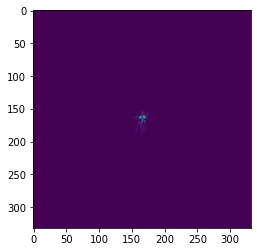

In [8]:
plt.imshow(psfs[0])

In [9]:
numpy.save('psf_file',psfs)

In [9]:
eedata=[]


for n in range(len(psfs)):
    e=aotools.encircled_energy(psfs[n], fraction=0.5, center=None, eeDiameter=True)
    eedata.append(e)

In [10]:
print(eedata)

[13.520361990950226, 13.770739064856713, 13.019607843137255, 13.26998491704374, 12.76923076923077, 23.535444947209655, 23.78582202111614, 23.78582202111614, 23.285067873303166, 22.53393665158371, 32.29864253393665, 32.29864253393665, 32.29864253393665, 30.79638009049774, 31.547511312217196, 37.80693815987934, 37.30618401206637, 37.30618401206637, 39.30920060331825, 37.55656108597285, 20.28054298642534, 20.28054298642534, 20.78129713423831, 20.530920060331823, 20.030165912518854, 19.279034690799396, 16.524886877828052, 18.277526395173453, 16.77526395173454, 18.02714932126697, 38.55806938159879, 38.808446455505276, 39.05882352941177, 38.808446455505276, 39.55957767722474, 40.81146304675716, 41.061840120663646, 41.061840120663646, 41.061840120663646, 41.31221719457014, 8.012066365007541, 8.763197586727, 8.512820512820513, 8.763197586727, 8.763197586727, 12.018099547511312, 12.268476621417797, 12.018099547511312, 12.76923076923077, 11.51734539969834, 19.279034690799396, 19.02865761689291, 

In [11]:
print(len(eedata))

250


Work out what unit this actually is - we could ask the aotools guys?

I believe it's the ee50d - the radius at which half the energy is encircled.

A bigger radius equal a crappier image

Makes sense as higher radii seem to be leading to lower sharpness values :)

ERICA images

In [12]:
imfolder='eccentricities'
im1_=Image.open(os.path.join(imfolder,os.listdir(imfolder)[0]))
im1=numpy.asarray(im1_)
w,h =im1.shape
imarray=numpy.zeros((5,w,h))


#make sure you match the 
files=os.listdir(imfolder)

for n in range(5):
    filename=files[n]
    im = Image.open(os.path.join(imfolder,filename))
    image=numpy.asarray(im)
    imarray[n]=image
    


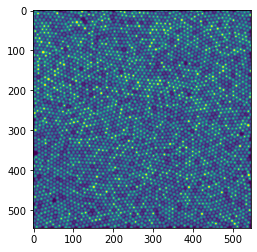

In [13]:
plt.imshow(imarray[1])

In [14]:
convarray1=numpy.zeros((frames,w,h))


In [20]:
ecc=3

get the convolutions - will have to do separately

In [21]:
l=0

image=imarray[ecc]
for m in range(frames):
    convolution = scipy.signal.convolve2d(image, psfs[m], mode='same',boundary='wrap')
    convarray1[l]=convolution
    print(l)
    l=l+1
        


IndexError: index 5 is out of bounds for axis 0 with size 5

we now have a big array of images.  Save this as a .npy?

In [ ]:
plt.imshow(convarray1[1])

In [ ]:
numpy.save('eccentricity%i_convolutions'%ecc,convarray1)

In [ ]:
dat=numpy.load('eccentricity%i_convolutions.npy'%ecc)

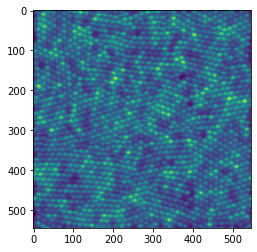

In [15]:
plt.imshow(dat[1])

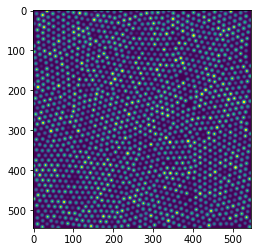

In [20]:
plt.imshow(imarray[4])

In [16]:
now calculate the sharpness metrics.  Should end up with a 3x5xframes array

SyntaxError: invalid syntax (<ipython-input-16-efd08bec4a6b>, line 1)

In [27]:
#import ERICA images for 5 eccentricities
#apply all aberrations to all images
#calculate 3x sharpness metrics for all images with all eccentricities

In [11]:
#plot 5x graphs, on each graph 3 sharpness metrics vs encircled energy, colour by sharpness metric.  Compare.